In [14]:
from utils import * 
import json
import itertools 
import networkx as nx
import subprocess
import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0) # All genes passing the filters in analysis-1.ipynb
print('Number of genomes:', genes_df.genome_id.nunique())
print('Number of genes:', len(genes_df))
# copy_structures(genes_df.index, source_dir='../data/genes/colabfold/', output_dir='../data/genes/colabfold/genes')

reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']

for row in genes_df.itertuples():
    if (row.genome_id in reverse_complement_genome_ids):
        genes_df.loc[row.Index, 'start'] = row.genome_size - (row.stop + 1)
        genes_df.loc[row.Index, 'stop'] = row.genome_size - (row.start - 1) 
        genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'

Number of genomes: 12
Number of genes: 1633


In [16]:
# Clustering with a combination of Foldseek and MMseqs does not appear to be sufficiently sensitive to capture gene
# conservation across Betazoid genomes. Instead, I am going to try a high-sensitivity all-versus-all MMseqs and Foldseek search. 

In [17]:
FOLDSEEK_QUERY_PATH = '../data/genes/colabfold/genes/'
FOLDSEEK_TARGET_PATH = FOLDSEEK_QUERY_PATH
FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/genes-genes.tsv'
FOLDSEEK_TMP_DIR = '../data/tmp/'
FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'

FOLDSEEK_PARAMS = dict()
FOLDSEEK_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
FOLDSEEK_PARAMS['--alignment-type'] = 1 # Make sure to actually align the structures.
FOLDSEEK_PARAMS['-a'] = '' # Add a backtrace string. 
FOLDSEEK_PARAMS['--format-output'] = FOLDSEEK_FIELDS 

cmd = f'foldseek easy-search {FOLDSEEK_QUERY_PATH} {FOLDSEEK_TARGET_PATH} {FOLDSEEK_OUTPUT_PATH} {FOLDSEEK_TMP_DIR}'
for param, value in FOLDSEEK_PARAMS.items():
    cmd += f' {param} {value}'
print(cmd)
# subprocess.run(cmd, shell=True, check=True)

foldseek_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, names=FOLDSEEK_FIELDS.replace('"','').split(','), sep='\t')
foldseek_df['pair_id'] = foldseek_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
foldseek_df = foldseek_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

filters = dict()
filters['self_alignments'] = foldseek_df['query'] == foldseek_df['target']
filters['duplicate_pairs'] = foldseek_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

foldseek_df = apply_filters(filters, foldseek_df)



foldseek easy-search ../data/genes/colabfold/genes/ ../data/genes/colabfold/genes/ ../data/genes/foldseek/genes-genes.tsv ../data/tmp/ -s 9.5 --alignment-type 1 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"
apply_filters: 759 entries removed by self_alignments.
apply_filters: 15786 entries removed by duplicate_pairs.


In [18]:
MMSEQS_QUERY_PATH = '../data/genes/genes.faa'
MMSEQS_TARGET_PATH = MMSEQS_QUERY_PATH
MMSEQS_OUTPUT_PATH = '../data/genes/mmseqs/genes-genes.tsv'
MMSEQS_TMP_DIR = '../data/tmp/'
MMSEQS_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"'

MMSEQS_PARAMS = dict()
MMSEQS_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
MMSEQS_PARAMS['-a'] = '' # Add a backtrace string. 
MMSEQS_PARAMS['--format-output'] = MMSEQS_FIELDS 

cmd = f'mmseqs easy-search {MMSEQS_QUERY_PATH} {MMSEQS_TARGET_PATH} {MMSEQS_OUTPUT_PATH} {MMSEQS_TMP_DIR}'
for param, value in MMSEQS_PARAMS.items():
    cmd += f' {param} {value}'
print(cmd)
# subprocess.run(cmd, shell=True, check=True)

mmseqs_df = pd.read_csv(MMSEQS_OUTPUT_PATH, names=MMSEQS_FIELDS.replace('"','').split(','), sep='\t')
mmseqs_df['pair_id'] = mmseqs_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
mmseqs_df = mmseqs_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

filters = dict()
filters['self_alignments'] = mmseqs_df['query'] == mmseqs_df['target']
filters['duplicate_pairs'] = mmseqs_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

mmseqs_df = apply_filters(filters, mmseqs_df)


mmseqs easy-search ../data/genes/genes.faa ../data/genes/genes.faa ../data/genes/mmseqs/genes-genes.tsv ../data/tmp/ -s 9.5 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"
apply_filters: 1592 entries removed by self_alignments.
apply_filters: 773 entries removed by duplicate_pairs.


In [19]:
# print('Number of Foldseek alignments:', len(foldseek_df))
# print('Number of MMseqs alignments:', len(mmseqs_df))

# palette = {'MMseqs':'gray', 'Foldseek':'steelblue'}
# fig, ax = plt.subplots(figsize=(4, 3))

# figure_df = mmseqs_df[['bits', 'evalue']].assign(source='MMseqs')
# figure_df = pd.concat([figure_df, foldseek_df[['bits', 'evalue']].assign(source='Foldseek')])

# sns.kdeplot(figure_df, x='bits', hue='source', common_norm=False, palette=palette)

# for source, df in figure_df.groupby('source'):
#     mean = df['bits'].mean()
#     ax.axvline(df['bits'].mean(), ls='--', color=palette.get(source))
#     ax.text(mean, ax.get_ylim()[-1], str(int(mean)), ha='center')


# ax.get_legend().set_title('')
# ax.set_xlim(xmax=500, xmin=0)

# plt.show()


In [20]:
graph = nx.Graph()

filter_ = (foldseek_df.qcov > 0.7) & (foldseek_df.tcov > 0.7)
filter_ = filter_ & (foldseek_df.alntmscore > 0.8)

filter_ = (mmseqs_df.qcov > 0.75) & (mmseqs_df.tcov > 0.75)
filter_ = filter_ & (mmseqs_df.bits > 40)

edges = [(row.query, row.target) for row in mmseqs_df[filter_].itertuples()]
# edges += [(row.query, row.target) for row in foldseek_df[filter_].itertuples()]
graph.add_edges_from(edges)
graph.add_nodes_from(genes_df.index.values)

clusters = list(nx.connected_components(graph))
clusters = sorted(clusters, key=len)[::-1]
clusters = {i:cluster for i, cluster in enumerate(clusters)}

cluster_df = pd.DataFrame.from_dict({gene_id:i for i, cluster in clusters.items() for gene_id in cluster}, orient='index', columns=['cluster_id'])
cluster_df = cluster_df.reset_index(names='gene_id')
cluster_df['genome_id'] = cluster_df.gene_id.apply(get_genome_id)
cluster_df = cluster_df[cluster_df.genome_id != 'bz_12'].copy()
cluster_df['cluster_num_genomes'] = cluster_df.groupby('cluster_id').genome_id.transform('nunique')
cluster_df['cluster_size'] = cluster_df.groupby('cluster_id').transform('size')

genes_df = genes_df.drop(columns=cluster_df.columns, errors='ignore')
genes_df = genes_df.merge(cluster_df.set_index('gene_id'), left_index=True, right_index=True, how='inner')
genes_df['length'] = genes_df.seq.apply(len)

with open('../data/genes/clusters.json', 'w') as f:
    json.dump(genes_df.cluster_id.to_dict(), f)



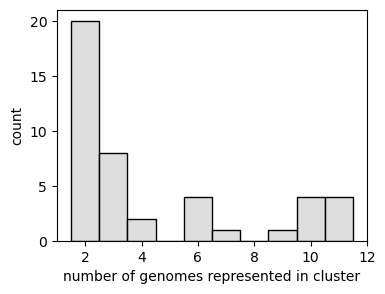

Number of clusters in 9 genomes: 1
Number of clusters in 10 genomes: 4
Number of clusters in 11 genomes: 4

Maximum number of cluster_0 genes in a genome: 1
Maximum number of cluster_1 genes in a genome: 1
Maximum number of cluster_2 genes in a genome: 1
Maximum number of cluster_3 genes in a genome: 1
Maximum number of cluster_4 genes in a genome: 1
Maximum number of cluster_5 genes in a genome: 1
Maximum number of cluster_6 genes in a genome: 1
Maximum number of cluster_7 genes in a genome: 1
Maximum number of cluster_8 genes in a genome: 1


In [49]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = cluster_df.drop_duplicates('cluster_id').copy()
figure_df = figure_df[figure_df.cluster_num_genomes > 1].copy()

# sns.histplot(figure_df, x='cluster_size', discrete=True, alpha=0.5, color='gray')
sns.histplot(figure_df, x='cluster_num_genomes', discrete=True, color='lightgray')
ax.set_ylabel('count')
ax.set_xlabel('number of genomes represented in cluster')
plt.show()

print('Number of clusters in 9 genomes:', (figure_df.cluster_size == 9).sum())
print('Number of clusters in 10 genomes:', (figure_df.cluster_size == 10).sum())
print('Number of clusters in 11 genomes:', (figure_df.cluster_size == 11).sum(), end='\n\n')

level_1_conserved_cluster_ids = genes_df[genes_df.cluster_num_genomes > 8].cluster_id.unique()
level_2_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 9) & (genes_df.cluster_num_genomes > 5)].cluster_id.unique()
level_3_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 6) & (genes_df.cluster_num_genomes > 1)].cluster_id.unique()

level_1_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_1_conserved_cluster_ids} 
level_2_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_2_conserved_cluster_ids} 
level_3_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_3_conserved_cluster_ids} 

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    print(f'Maximum number of cluster_{cluster_id} genes in a genome:', df.genome_id.value_counts().max())

In [50]:
# print('Highly-conserved cluster IDs:', level_1_conserved_cluster_ids.tolist())
# print('Moderately-conserved cluster IDs:', level_2_conserved_cluster_ids.tolist())
# print('Weakly-conserved cluster IDs:', level_3_conserved_cluster_ids.tolist())

print('level_1_conserved_cluster_ids =', level_1_conserved_cluster_ids.tolist())
print('level_2_conserved_cluster_ids =', level_2_conserved_cluster_ids.tolist())
print('level_3_conserved_cluster_ids =', level_3_conserved_cluster_ids.tolist())

level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]


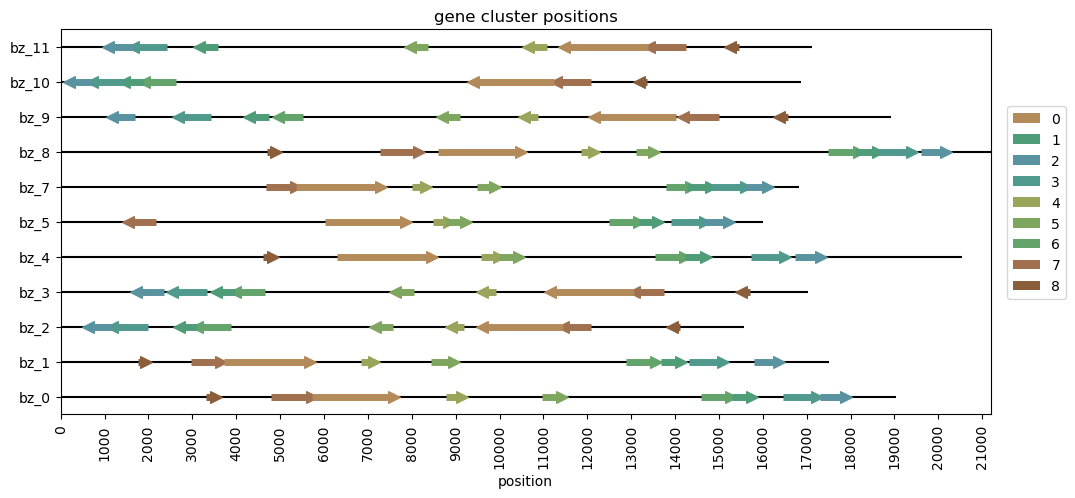

In [51]:
figure_df = genes_df[genes_df.cluster_num_genomes >= 9].copy()
figure_df['genome_number'] = pd.factorize(figure_df.genome_id)[0]
figure_df = figure_df.sort_values('genome_number')
figure_df['gene_id'] = figure_df.index
figure_df = figure_df.reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#5E5247','#6C6154','#7B7061','#8A8170','#84886C','#737F69','#65776B','#5F7472','#63727D','#676F88','#6B6B93']
colors = ['#6A5A4B', '#7A6956', '#8B7A62', '#9A8B68','#8B9164','#768C66','#64836C','#5D7F76','#607B83','#66778C','#6B6F91']
colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', '#4F9A8C', '#5A93A0', '#6A89B0', '#7A7FB8']

palette = dict(zip(figure_df.cluster_id.unique(), colors))

for row in figure_df.drop_duplicates('genome_id').itertuples():
    # ax.axhline(row.genome_number, color='black', xmin=0, xmax=row.genome_size, zorder=-1)
    ax.hlines(y=row.genome_number, color='black', xmin=0, xmax=row.genome_size, zorder=-1)

for row in figure_df.itertuples():
    ax.hlines(y=[row.genome_number], xmin=row.start, xmax=row.stop, linewidth=5, color=palette[row.cluster_id])
    if row.strand == '+':
        ax.scatter([row.stop], [row.genome_number], s=70, marker='>', color=palette[row.cluster_id])
    elif row.strand == '-':
        ax.scatter([row.start], [row.genome_number], s=70, marker='<', color=palette[row.cluster_id])

labels = sorted(list(palette.keys()))
handles = [Patch(facecolor=palette[cluster_id], label=cluster_id) for cluster_id in labels]
ax.legend(handles, labels, bbox_to_anchor=(1.01, 0.55), loc='center left')

ax.set_xlim(xmin=0, xmax=figure_df.genome_size.max())
ax.set_yticks(figure_df.genome_number.unique(), labels=figure_df.genome_id.unique())
ax.set_xticks(np.arange(0, 22000, 1000), labels=np.arange(0, 22000, 1000), rotation=90)
ax.set_xlabel('position')
ax.set_title('gene cluster positions')
plt.show()
# Need to check if proteins in clusters 1 and 2 interact. 

In [52]:
for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    info = f'cluster_{cluster_id}'
    info += f'\tlengths: {df.length.min()} - {df.length.max()}'
    info += f'\tany/all predicted by Prodigal: {np.any(~df.prodigal_gene_id.isnull())}/{np.all(~df.prodigal_gene_id.isnull())}'
    print(info)
# mmseqs_df[mmseqs_df['query'].isin(cluster_0_gene_ids) & mmseqs_df['target'].isin(cluster_0_gene_ids)]

cluster_0	lengths: 610 - 715	any/all predicted by Prodigal: True/True
cluster_1	lengths: 138 - 153	any/all predicted by Prodigal: True/True
cluster_2	lengths: 173 - 196	any/all predicted by Prodigal: True/True
cluster_3	lengths: 244 - 266	any/all predicted by Prodigal: True/True
cluster_4	lengths: 90 - 125	any/all predicted by Prodigal: True/True
cluster_5	lengths: 126 - 149	any/all predicted by Prodigal: True/True
cluster_6	lengths: 177 - 253	any/all predicted by Prodigal: True/True
cluster_7	lengths: 207 - 311	any/all predicted by Prodigal: True/True
cluster_8	lengths: 53 - 69	any/all predicted by Prodigal: True/True


In [53]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']

annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)


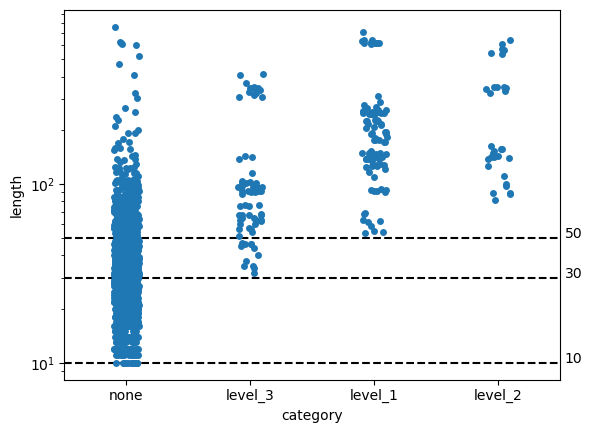

In [59]:
fig, ax = plt.subplots()

figure_df = genes_df.copy()

categories = dict()
categories['level_1'] = figure_df.index.isin([gene_id for gene_ids in level_1_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_2'] = figure_df.index.isin([gene_id for gene_ids in level_2_conserved_cluster_gene_ids.values() for gene_id in gene_ids])
categories['level_3'] = figure_df.index.isin([gene_id for gene_ids in level_3_conserved_cluster_gene_ids.values() for gene_id in gene_ids])

categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')

sns.stripplot(figure_df, x='category', y='length')

for y in [10, 30, 50]:
    ax.axhline(y, ls='--', color='black')
    ax.text(ax.get_xlim()[-1] * 1.01, y, str(y))
ax.set_yscale('log')

In [48]:
[gene_id for gene_ids in level_2_conserved_cluster_gene_ids.values() for gene_id in gene_ids]

['orfm.bz_0.1_54',
 'orfm.bz_1.1_21',
 'orfm.bz_2.1_142',
 'orfm.bz_3.1_169',
 'orfm.bz_4.1_69',
 'orfm.bz_8.1_70',
 'orfm.bz_9.1_173',
 'orfm.bz_10.1_121',
 'orfm.bz_11.1_163',
 'orfm.bz_0.1_82',
 'orfm.bz_1.1_43',
 'orfm.bz_2.1_117',
 'orfm.bz_3.1_142',
 'orfm.bz_5.1_26',
 'orfm.bz_7.1_68',
 'orfm.bz_8.1_106',
 'orfm.bz_9.1_152',
 'orfm.bz_10.1_110',
 'orfm.bz_11.1_147',
 'orfm.bz_0.1_98',
 'orfm.bz_1.1_59',
 'orfm.bz_2.1_112',
 'orfm.bz_3.1_135',
 'orfm.bz_4.1_107',
 'orfm.bz_5.1_95',
 'orfm.bz_7.1_89',
 'orfm.bz_8.1_128',
 'orfm.bz_9.1_140',
 'orfm.bz_10.1_101',
 'orfm.bz_11.1_140',
 'orfm.bz_0.1_118',
 'orfm.bz_1.1_79',
 'orfm.bz_2.1_92',
 'orfm.bz_3.1_94',
 'orfm.bz_4.1_126',
 'orfm.bz_5.1_103',
 'orfm.bz_7.1_105',
 'orfm.bz_8.1_149',
 'orfm.bz_9.1_105',
 'orfm.bz_11.1_113',
 'orfm.bz_0.1_138',
 'orfm.bz_1.1_95',
 'orfm.bz_2.1_72',
 'orfm.bz_3.1_82',
 'orfm.bz_4.1_128',
 'orfm.bz_5.1_105',
 'orfm.bz_7.1_119',
 'orfm.bz_8.1_164',
 'orfm.bz_9.1_90',
 'orfm.bz_11.1_85',
 'orfm.bz_0.

In [37]:
list(zip(*categories.items()))[::-1]

[(array([False, False, False, ..., False, False, False], shape=(1528,)),
  array([False, False, False, ..., False, False, False], shape=(1528,)),
  array([False, False, False, ..., False, False, False], shape=(1528,))),
 ('level_1', 'level_2', 'level_3')]

In [45]:
level_1_conserved_cluster_ids

array([8, 7, 0, 4, 5, 6, 1, 3, 2])